<a href="https://colab.research.google.com/github/pejmanrasti/EPU_ML_Angers_2026/blob/main/Jour_3/DL_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Make your fist experience with Tensorflow-Keras**
Our goal is to construct and train an artificial neural network on thousands of images of handwritten digits so that it may successfully identify others when presented. The data that will be incorporated is the MNIST database which contains 60,000 images for training and 10,000 test images.

## Loading Training and Validation Data

The MNIST dataset is conveniently bundled within Keras, and we can easily analyze some of its features in Python.

# **Importing necessary Libraries**

In [28]:
from __future__ import absolute_import, division, print_function, unicode_literals
import tensorflow as tf
import os
import cv2
import random
import numpy as np
from glob import glob
import matplotlib.image as mpimg
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential,Model # Model type to be used
from tensorflow.keras.layers import Dense, Activation, Dropout# Make Fully connected (FC) layers
from tensorflow.keras.utils import to_categorical # NumPy related tools
from tensorflow.keras.callbacks import TensorBoard  #Visulization of Accuracy and loss
from tensorboardcolab import TensorBoardColab, TensorBoardColabCallback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

In [29]:
from google.colab import drive
root = '/content/gdrive/'
drive.mount( root )

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [30]:
!unzip /content/gdrive/MyDrive/Formation_ICO/Jour1/data.zip

Archive:  /content/gdrive/MyDrive/Formation_ICO/Jour1/data.zip
replace __MACOSX/._Mild_Demented? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [31]:
#Dataset that should go with Alzheimer label
very_mild = glob('Very_Mild_Demented/*')
mild = glob('Mild_Demented/*')
moderate = glob('Moderate_Demented/*')

#Dataset without Alzheimer
non = glob('Non_Demented/*')

Visualization of some input images

Non_Demented/non_1641.jpg
One of the data in Non Alzheimer Folder
Image shape:(128, 128)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
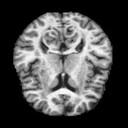

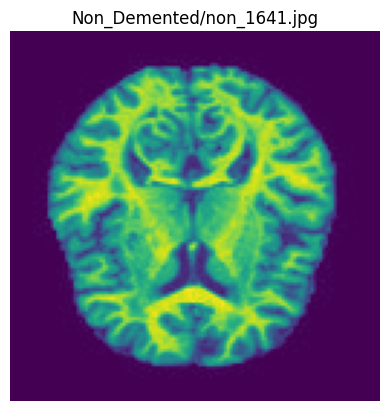

In [32]:
print(non[1])
def view_image(directory):
    img = mpimg.imread(directory)
    plt.imshow(img)
    plt.title(directory)
    plt.axis('off')
    print(f'Image shape:{img.shape}')
    return img

print('One of the data in Non Alzheimer Folder')
view_image(non[1])

Alzheimer Patient's Brain
Image shape:(128, 128)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
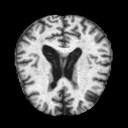

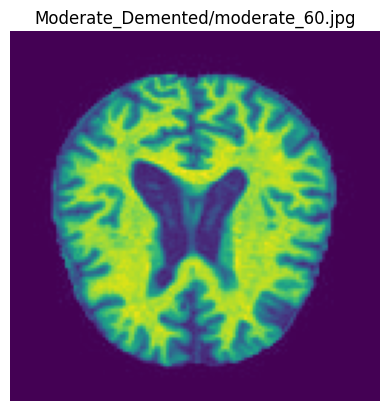

In [33]:
print('Alzheimer Patient\'s Brain')
view_image(moderate[1])

## Formatting the input data layer

Instead of a 28 x 28 matrix, we build our network to accept a 784-length vector. Each image needs to be then reshaped (or flattened) into a vector.

In [34]:
from sklearn.model_selection import train_test_split

#List where arrays shall be stored
resized_image_array=[]
#List that will store the answer if an image is female (0) or male (1)
resized_image_array_label=[]

width = 128
height = 128
new_size = (width,height) #the data is just black to white

#Iterate over pictures and resize them to 128 by 128
def resizer(image_directory):
    for file in image_directory: #tried with os.listdir but could work with os.walk as well
        img = Image.open(file) #just putting image_directory or file does not work for google colab, interesting.
        #preserve aspect ratio
        img = img.resize(new_size)
        array_temp = np.array(img)
        shape_new = width*height
        img_wide = array_temp.reshape(1, shape_new)
        resized_image_array.append(img_wide[0])
        if image_directory == non:
            resized_image_array_label.append(0)
        elif image_directory == very_mild:
            resized_image_array_label.append(1)
        elif image_directory == mild:
            resized_image_array_label.append(2)
        else:
            resized_image_array_label.append(3)

resizer(non)
resizer(very_mild)
resizer(mild)
resizer(moderate)

#split the data to test and training
train_x_temp, test_x, train_y_temp, test_y = train_test_split(resized_image_array, resized_image_array_label, test_size = 0.2)
train_x, val_x, train_y, val_y = train_test_split(train_x_temp, train_y_temp, test_size = 0.2)

# Convert lists to NumPy arrays for Keras input
train_x = np.array(train_x)
val_x = np.array(val_x)
test_x = np.array(test_x)

# Normalize inputs from 0-255 to 0-1
train_x = train_x.astype('float32') / 255
val_x = val_x.astype('float32') / 255
test_x = test_x.astype('float32') / 255

In [35]:
train_x.shape

(4096, 16384)

In [36]:
! pip install livelossplot
from livelossplot import PlotLossesKeras
plotlosses = PlotLossesKeras()

We then modify our classes (unique digits) to be in the one-hot format, i.e.

In [37]:
# one hot encode outputs
Y_train = to_categorical(train_y)
Y_val = to_categorical(val_y)
Y_test = to_categorical(test_y)

# Building the simplest fully connected network (FCN) with just one layer

In [38]:
# The Sequential model is a linear stack of layers and is very common.
# The input shape is 128x128 = 16384
model = Sequential([
    Dense(4,input_shape=(16384,)), # It is the output layer and should be equal to the number of desired classes (10 in this case).
    Activation('softmax'),
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 4)              │        65,540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,540 (256.02 KB)

 Trainable params: 65,540 (256.02 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling the model

Keras is built on top of TensorFlow. It allows you to define a *computation graph* in Python, which then compiles and runs efficiently on the CPU or GPU without the overhead of the Python interpreter.

When compiling a model, Keras asks you to specify your **loss function** and your **optimizer**. The loss function we'll use here is called *categorical cross-entropy*, and is a loss function well-suited to comparing two probability distributions.

Our predictions are probability distributions across the ten different digits (e.g. "we're 80% confident this image is a 3, 10% sure it's an 8, 5% it's a 2, etc."), and the target is a probability distribution with 100% for the correct category, and 0 for everything else. The cross-entropy is a measure of how different your predicted distribution is from the target distribution. [More detail at Wikipedia](https://en.wikipedia.org/wiki/Cross_entropy)

In [39]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

## Train the model!

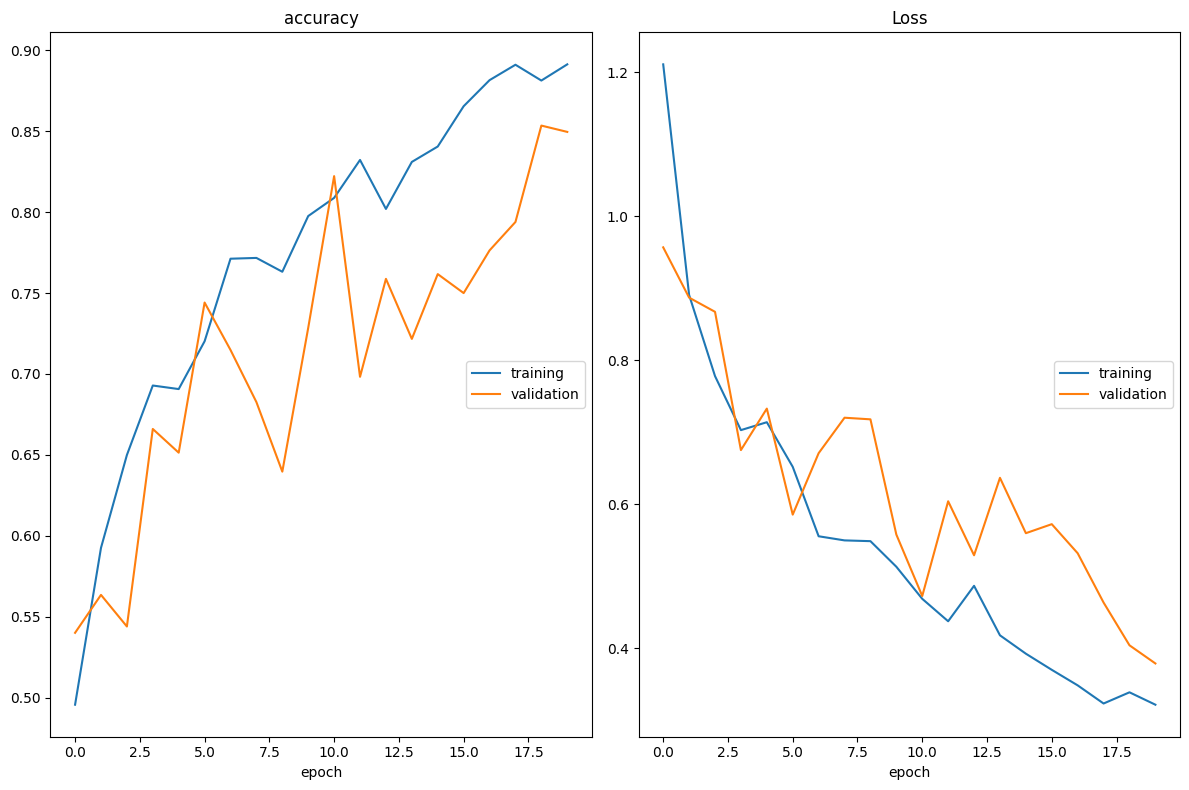

accuracy
	training         	 (min:    0.496, max:    0.891, cur:    0.891)
	validation       	 (min:    0.540, max:    0.854, cur:    0.850)
Loss
	training         	 (min:    0.322, max:    1.211, cur:    0.322)
	validation       	 (min:    0.379, max:    0.957, cur:    0.379)
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8914 - loss: 0.3218 - val_accuracy: 0.8496 - val_loss: 0.3790


In [40]:
model.fit(train_x, Y_train,
          validation_data=(val_x, Y_val),
          epochs=20, batch_size=32,
          verbose=1,
          callbacks=[plotlosses])

## Evaluate Model's Accuracy on Test Data
Your test data **Must** be different from the validation data, but in this example, we will use the validation data as the test data as well.

In [41]:
score = model.evaluate(test_x, Y_test)
print('Test score:', score[0])
print('Test accuracy:', score[1])

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8602 - loss: 0.3738
Test score: 0.373797208070755
Test accuracy: 0.860156238079071


### Inspecting the output

It's always a good idea to inspect the output and make sure everything looks sane. Here we'll look at some examples it gets right, and some examples it gets wrong.

In [42]:
# The predict_classes function outputs the highest probability class
# according to the trained classifier for each input example.
predicted_classes = np.argmax(model.predict(val_x), axis=-1)

# Check which items we got right / wrong
correct_indices = np.nonzero(predicted_classes == val_y)[0]

incorrect_indices = np.nonzero(predicted_classes != val_y)[0]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


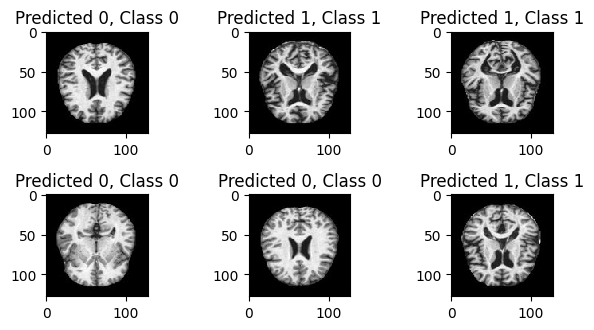

In [43]:
plt.figure()
for i, correct in enumerate(correct_indices[:6]):
    plt.subplot(3,3,i+1)
    # Reshape the 16384-length vector back to 128x128 for plotting
    plt.imshow(val_x[correct].reshape(128,128), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct], val_y[correct]))

plt.tight_layout()

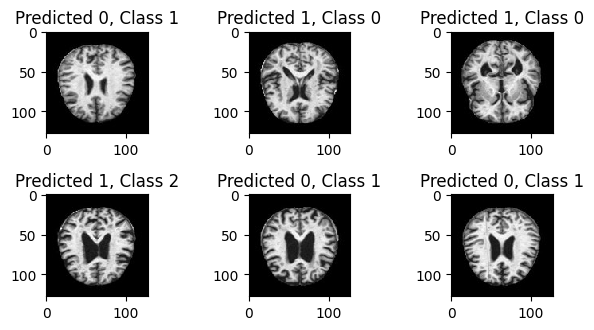

In [44]:
plt.figure()
for i, incorrect in enumerate(incorrect_indices[:6]):
    plt.subplot(3,3,i+1)
    # Reshape the 16384-length vector back to 128x128 for plotting
    plt.imshow(val_x[incorrect].reshape(128,128), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect], val_y[incorrect]))

plt.tight_layout()

# **Let's go Deeper**
We will add four more layers to our model. We use Droupout in our model to reduce overfitting

In [45]:
# Dropout helps protect the model from memorizing or "overfitting" the training data.
Pkeep=0.25
modelDeepFC = Sequential([
    Dense(200, input_shape=(16384,)), # Update input shape to 128x128 = 16384
    Activation('relu'),
    Dropout(Pkeep),
    Dense(100, input_shape=(200,)),
    Activation('relu'),
    Dropout(Pkeep),
    Dense(60, input_shape=(100,)),
    Activation('relu'),
    Dropout(Pkeep),
    Dense(30, input_shape=(60,)),
    Activation('relu'),
    Dropout(Pkeep),
    Dense(len(np.unique(resized_image_array_label))), # Output layer should match the number of unique labels
    Activation('softmax'),
])

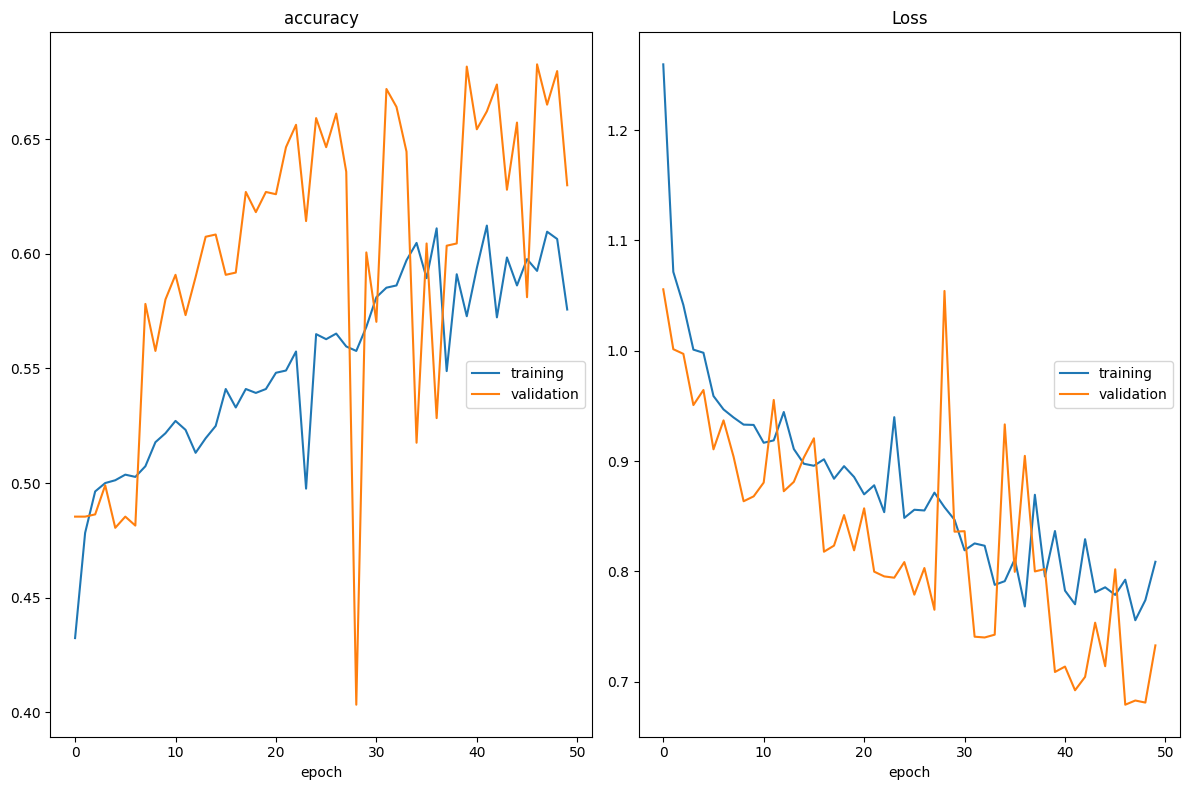

accuracy
	training         	 (min:    0.432, max:    0.612, cur:    0.576)
	validation       	 (min:    0.403, max:    0.683, cur:    0.630)
Loss
	training         	 (min:    0.756, max:    1.260, cur:    0.809)
	validation       	 (min:    0.679, max:    1.056, cur:    0.733)
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5757 - loss: 0.8087 - val_accuracy: 0.6299 - val_loss: 0.7329


In [46]:
plotlossesdeep = PlotLossesKeras()
modelDeepFC.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

modelDeepFC.fit(train_x, Y_train,
          validation_data=(val_x, Y_val),
          epochs=50, batch_size=32,
          verbose=1,
          callbacks=[plotlossesdeep])

The performance of the last model with more layers showed a better performance compare with our first model.

# **Let's go furter with introducing CNN**
Before, we built a network that accepts the normalized pixel values of each value and operates soley on those values. What if we could instead feed different features (e.g. curvature, edges) of each image into a network, and have the network learn which features are important for classifying an image?

This possible through convolution! Convolution applies kernels (filters) that traverse through each image and generate feature maps.

In [47]:
# import some additional tools
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

In [48]:
# Clear the lists before repopulating for 2D images
resized_image_array = []
resized_image_array_label = []

def resizer2D(image_directory):
    for file in image_directory: #tried with os.listdir but could work with os.walk as well
        img = Image.open(file) #just putting image_directory or file does not work for google colab, interesting.
        #preserve aspect ratio
        img = img.resize(new_size)
        array_temp = np.array(img)
        resized_image_array.append(array_temp) # Append the whole 2D array, not just the first row
        if image_directory == non:
            resized_image_array_label.append(0)
        elif image_directory == very_mild:
            resized_image_array_label.append(1)
        elif image_directory == mild:
            resized_image_array_label.append(2)
        else:
            resized_image_array_label.append(3)

resizer2D(non)
resizer2D(very_mild)
resizer2D(mild)
resizer2D(moderate)

#split the data to test and training
train_x_temp, test_x, train_y_temp, test_y = train_test_split(resized_image_array, resized_image_array_label, test_size = 0.1)
train_x, val_x, train_y, val_y = train_test_split(train_x_temp, train_y_temp, test_size = 0.2)

# Convert lists to NumPy arrays for Keras input
train_x = np.array(train_x)
val_x = np.array(val_x)
test_x = np.array(test_x)

# Normalize inputs from 0-255 to 0-1
train_x = train_x.astype('float32') / 255
val_x = val_x.astype('float32') / 255
test_x = test_x.astype('float32') / 255

In [49]:
# Add a channel dimension for CNN input (grayscale images have 1 channel)
train_x = train_x.reshape(train_x.shape[0], 128, 128, 1)
val_x = val_x.reshape(val_x.shape[0], 128, 128, 1)
test_x = test_x.reshape(test_x.shape[0], 128, 128, 1)

print("Training shape with channel", train_x.shape)
print("Validation shape with channel", val_x.shape)
print("Testing shape with channel", test_x.shape)

Training shape with channel (4608, 128, 128, 1)
Validation shape with channel (1152, 128, 128, 1)
Testing shape with channel (640, 128, 128, 1)


In [50]:
Y_train = to_categorical(train_y)
Y_val = to_categorical(val_y)
Y_test = to_categorical(test_y)

In [51]:
modelCNN = Sequential([

    # Convolution Layer 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)), # Corrected input_shape for 128x128 images
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Layer 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Layer 3
    Conv2D(128, (3, 3), activation='relu'),

    Flatten(), # Flatten final output into a vector

    # Fully Connected Layer 4
    Dense(512), # This will result in a very large number of parameters (100352 * 512), consider reducing if memory is an issue
    Activation('relu'),
    Dropout(0.2),
    Dense(len(np.unique(resized_image_array_label))), # Output layer should match the number of unique labels (4 classes)
    Activation('softmax'),
])
modelCNN.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │         2,052 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,475,460 (196.36 MB)

 Trainable params: 51,475,460 (196.36 MB)

 Non-trainable params: 0 (0.00 B)

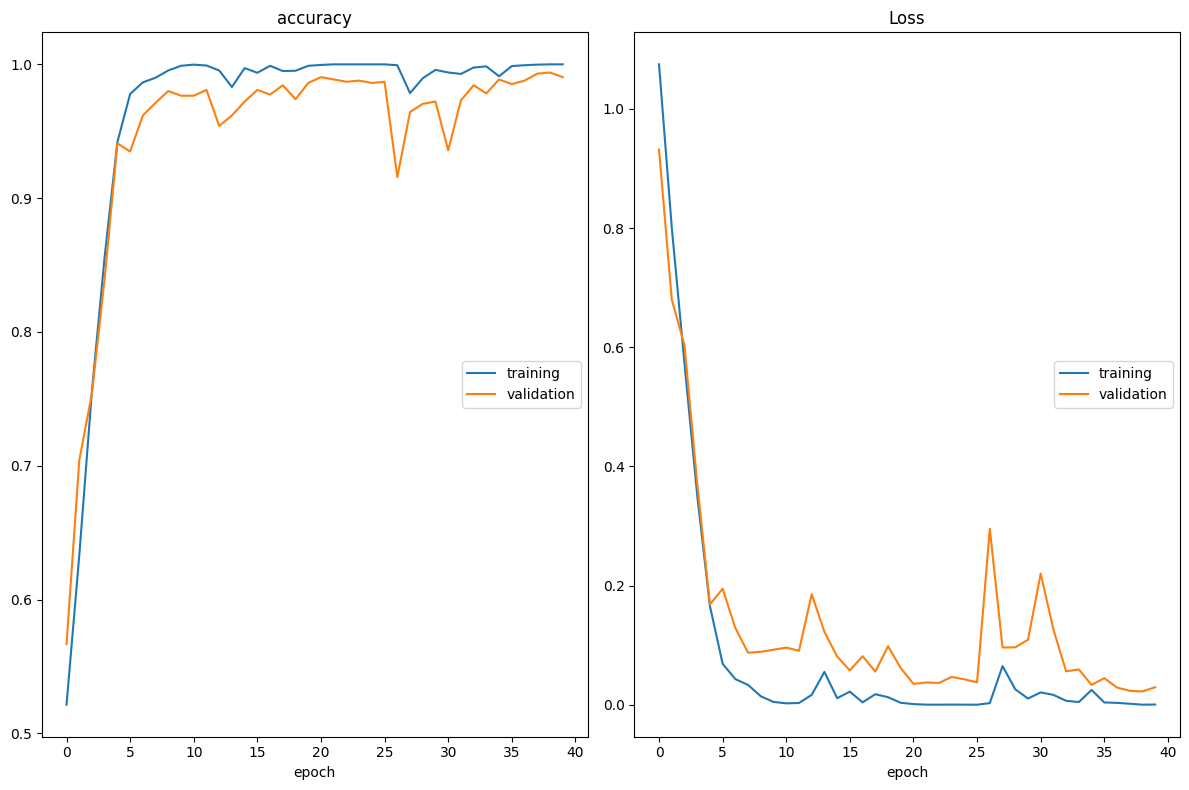

accuracy
	training         	 (min:    0.521, max:    1.000, cur:    1.000)
	validation       	 (min:    0.567, max:    0.994, cur:    0.990)
Loss
	training         	 (min:    0.000, max:    1.075, cur:    0.000)
	validation       	 (min:    0.022, max:    0.932, cur:    0.029)
144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 1.0000 - loss: 3.1625e-04 - val_accuracy: 0.9905 - val_loss: 0.0294


In [52]:
plotlossesCNN = PlotLossesKeras()
modelCNN.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

modelCNN.fit(train_x, Y_train,
          validation_data=(val_x, Y_val),
          epochs=40, batch_size=32,
          verbose=1,
          callbacks=[plotlossesCNN])

**Evaluation and Prediction**

We can use our model to make a prediction on new images.

In [53]:
modelCNN.evaluate(test_x,Y_test) #Evaluation of the model on the test dataset

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9891 - loss: 0.0508


[0.05079708620905876, 0.989062488079071]

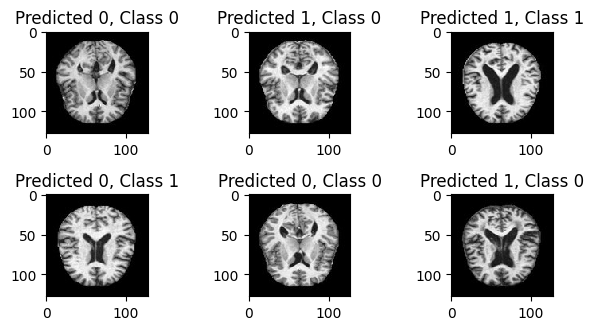

In [55]:
plt.figure()
for i, correct in enumerate(correct_indices[:6]):
    plt.subplot(3,3,i+1)
    # Reshape the 16384-length vector back to 128x128 for plotting
    plt.imshow(val_x[correct].reshape(128,128), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct], val_y[correct]))

plt.tight_layout()

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


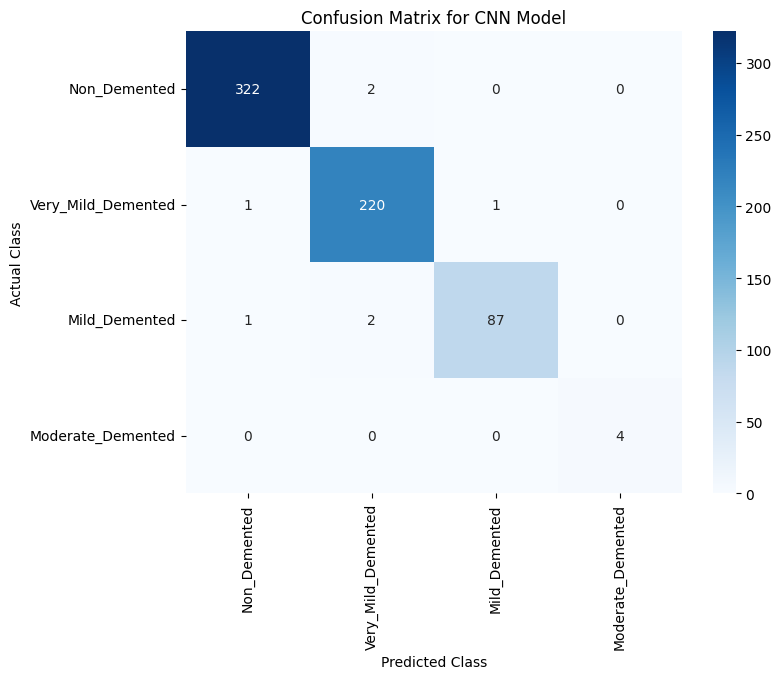

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions from the CNN model on the test set
Y_pred_cnn = modelCNN.predict(test_x)

# Convert predictions from probabilities to class labels
y_pred_classes_cnn = np.argmax(Y_pred_cnn, axis=1)

# Convert one-hot encoded true labels to class labels
y_true_classes = np.argmax(Y_test, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes_cnn)

# Define class labels for better readability
class_names = ['Non_Demented', 'Very_Mild_Demented', 'Mild_Demented', 'Moderate_Demented']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for CNN Model')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()